In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\91995\NIT\46_Logistic Regression\logit classification.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [2]:
X=df.iloc[:,[2,3]].values
y=df.iloc[:,-1].values

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [4]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(X_train,y_train)

LogisticRegression()

In [6]:
y_pred=classifier.predict(X_test)

In [7]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

In [8]:
y_pred # if we see carefully 1 value is predicted wrong 

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [9]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[65  3]
 [ 8 24]]


In [10]:
# tp-65
# tn-24
# fp-3
# fn-8

In [11]:
from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test,y_pred)
print(ac)

0.89


In [12]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



In [13]:
# 25% test with scaling accuracy-89%
# 20% test with scaling accuracy is 92.50%
# 25% test with scaling accuracy-89%
# 20% test with scaling accuracy is 91.25%

# Future Prediction

In [15]:
dataset=pd.read_csv(r"C:\Users\91995\NIT\46_Logistic Regression\Future prediction1.csv")
dataset

,User ID,Gender,Age,EstimatedSalary
0,15724611,Male,45,60000
1,15725621,Female,79,64000
2,15725622,Male,23,78000
3,15720611,Female,34,45000
4,15588044,Male,29,76000
5,15746039,Female,70,89000
6,15704887,Male,86,120000
7,15746009,Female,46,23000
8,15876009,Male,32,70000
9,15886009,Female,100,90000


In [17]:
d2=dataset.copy()

In [18]:
d2

,User ID,Gender,Age,EstimatedSalary
0,15724611,Male,45,60000
1,15725621,Female,79,64000
2,15725622,Male,23,78000
3,15720611,Female,34,45000
4,15588044,Male,29,76000
5,15746039,Female,70,89000
6,15704887,Male,86,120000
7,15746009,Female,46,23000
8,15876009,Male,32,70000
9,15886009,Female,100,90000


In [20]:
dataset1=dataset.iloc[:,[2,3]].values

In [21]:
from sklearn.preprocessing import StandardScaler 
sc=StandardScaler()
M=sc.fit_transform(dataset1)

In [22]:
y_pred1=pd.DataFrame()

In [23]:
d2['y_pred1']=classifier.predict(M)

In [24]:
d2.to_csv('final1.csv')

In [25]:
import os

In [26]:
os.getcwd()

'C:\\Users\\91995\\NIT\\46_Logistic Regression'

In [27]:
## if the regression model can you predict future--yes/no
   ### future prediction are-- numbers(continuous variable)
## if classication model can you predict future--yes
    ### future prediction are binary(0/1)

# AUC and ROC curve

In [28]:
# Area under curve
# Receiver operating characteristic

In [29]:
# High roc means more aoc means better accuracy

In [30]:
from sklearn.metrics import roc_auc_score,roc_curve
y_pred_prob=classifier.predict_proba(X_test)[:,1]

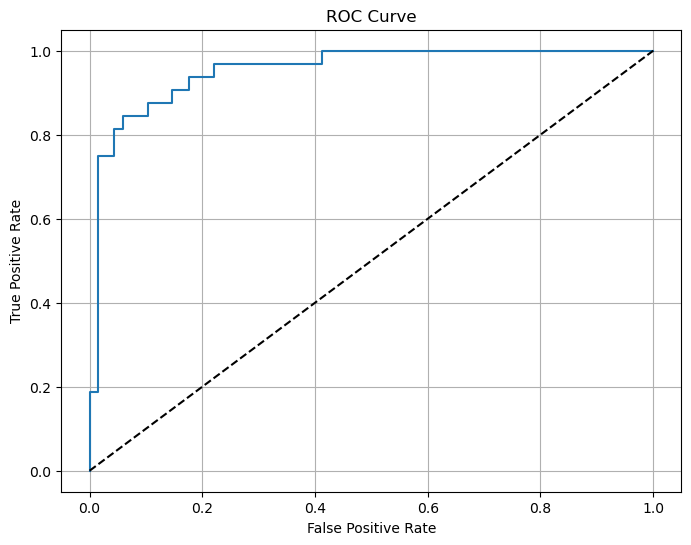

In [32]:
auc_score=roc_auc_score(y_test,y_pred_prob)
auc_score

fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'Logistic Regression')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()
plt.show()